# Demonstrating Simple Backpropagation

In this notebook, we demonstrate the backpropagation algorithm using PyTorch to train a simple neural network on a toy dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)

## 1. Create a Dummy Dataset
We will create a simple non-linear dataset (e.g., a quadratic function with some noise) to train our network.

Dummy dataset created with shape/dimension:
torch.Size([100, 1])
100 rows, 1 column


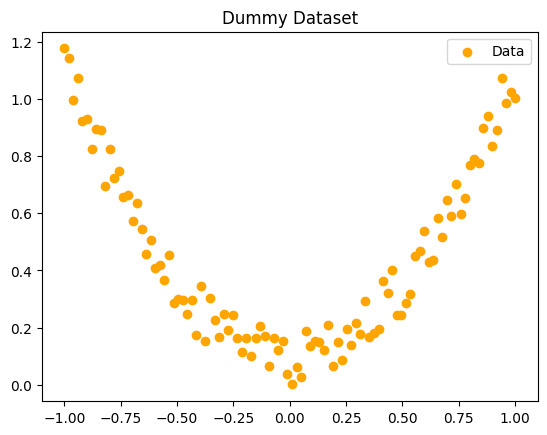

In [2]:
# Generate 100 data points (random from 0 <= x < 1)
X = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)

# Function f(x); y = x^2 + noise - as the ground-truth
y = X.pow(2) + 0.2 * torch.rand(X.size())  

# Show dataset
print(f"Dummy dataset created with shape/dimension:\n{X.shape}")
print(f"{X.shape[0]} rows, {X.shape[1]} column")

# Plot the dataset
plt.scatter(X.numpy(), y.numpy(), color='orange', label='Data')
plt.title('Dummy Dataset')
plt.legend()
plt.show()

## 2. Define a Simple Neural Network
We create a neural network with one hidden layer.

In [3]:
# Class definition for simple neural network
class SimpleNet(nn.Module):
    def __init__(self):
        # inheriting Pytorch's base class for all neural network modules
        super(SimpleNet, self).__init__()
        
        self.hidden = nn.Linear(1, 10)   # Hidden layer with 10 neurons
        self.relu = nn.ReLU()            # Activation function (ReLU)
        self.output = nn.Linear(10, 1)   # Output layer

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model = SimpleNet()
# Print out the model initalization
print("Simple NN initialized and ready")
print(model)


Simple NN initialized and ready
SimpleNet(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=10, out_features=1, bias=True)
)


## 3. Loss Function and Optimizer
We use Mean Squared Error (MSE) for our loss function. For the optimizer, there are several popular choices.
Here we provide a few commonly used ones (SGD, Adam, RMSprop). You can uncomment the one you want to try!

In [ ]:
# --- Popular Loss Functions ---
loss_name = 'Huber' # Options: 'MSE', 'L1', 'Huber'

if loss_name == 'MSE':
    # Mean Squared Error: standard for regression.
    criterion = nn.MSELoss()
elif loss_name == 'L1':
    # L1 Loss (MAE): more robust to outliers.
    criterion = nn.L1Loss()
elif loss_name == 'Huber':
    # Huber Loss: less sensitive to outliers than MSE.
    criterion = nn.HuberLoss()
else:
    raise ValueError(f"Unsupported loss function: {loss_name}")

print(f"Criterion/Loss function '{loss_name}' is initialized and ready: {criterion}\n")

# --- Popular Optimizers ---
optimizer_name = 'Adam' # Options: 'SGD', 'Adam', 'RMSprop'
learning_rate = 0.1

if optimizer_name == 'SGD':
    # The classic, often needs careful learning rate tuning.
    optimizer = optim.SGD(model.parameters(), learning_rate)
elif optimizer_name == 'Adam':
    # Very popular, adapts learning rate per parameter.
    optimizer = optim.Adam(model.parameters(), learning_rate)
elif optimizer_name == 'RMSprop':
    # Good for handling non-stationary objectives.
    optimizer = optim.RMSprop(model.parameters(), learning_rate)
else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

print("Optimizer function is initialized and ready")
print(optimizer)


Criterion/Loss function 'Huber' is initialized and ready: HuberLoss()

Optimizer function is initialized and ready
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 4. Training Loop
This is where backpropagation happens. The steps are:
1. **Forward pass:** Compute predicted y by passing X to the model.
2. **Compute loss:** Compare predicted y with true y.
3. **Zero gradients:** Clear old gradients from the last step.
4. **Backward pass (Backpropagation):** Compute the derivative of the loss w.r.t. the parameters (using `loss.backward()`).
5. **Optimizer step:** Update the parameters (using `optimizer.step()`).

In [5]:
# set number of epochs (number of trainings)
epochs = 200
# stored the loss value after MSE calculation
losses = []

for epoch in range(epochs):
    # 1. Forward pass
    #   Calling the simpleNN object 'model' to output y_pred
    y_pred = model(X)
    
    # 2. Compute loss
    #   Calculate the MSE loss by comparing y_pred and y (ground-truth)
    loss = criterion(y_pred, y)
    # Store the loss value inside losses array
    losses.append(loss.item())
    
    # 3. Zero gradients
    #   for starting up: to clears out the old gradients or slope from previous training steps
    optimizer.zero_grad()
    
    # 4. Backward pass (Backpropagation)
    #   Calculate new gradients/slope (weight) based on current loss
    loss.backward()
    
    # 5. Optimizer step
    #   Use the new gradients/slope (weight) and update into NN
    optimizer.step()
    
    if (epoch + 1) % 40 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [40/200], Loss: 0.0512
Epoch [80/200], Loss: 0.0429
Epoch [120/200], Loss: 0.0404
Epoch [160/200], Loss: 0.0387
Epoch [200/200], Loss: 0.0372


## 5. Visualize Results
Let's see how well our model fits the data after training.

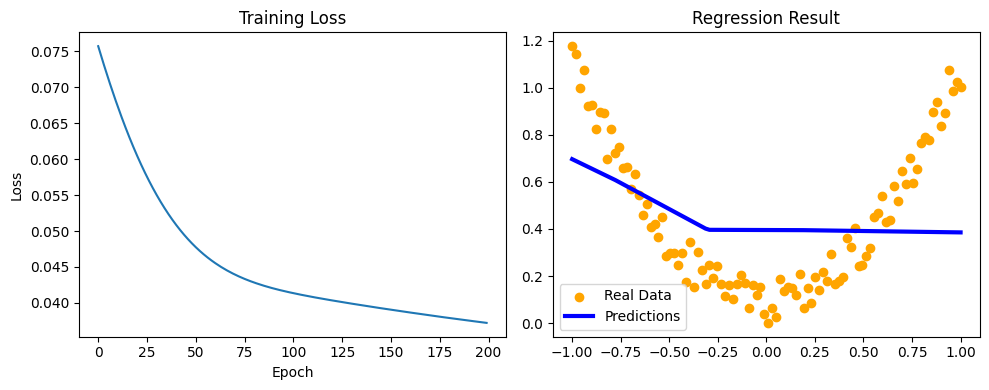

In [6]:
# Plot the training loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

# Plot the original data and the model's predictions
# Comparing y_pred vs y (ground-truth)
plt.subplot(1, 2, 2)
plt.scatter(X.numpy(), y.numpy(), color='orange', label='Real Data')
with torch.no_grad(): # No need to track gradients for inference
    predicted = model(X).numpy()
plt.plot(X.numpy(), predicted, color='blue', linewidth=3, label='Predictions')
plt.title('Regression Result')
plt.legend()

plt.tight_layout()
plt.show()